# Solution 2.1: Loading, Inspecting and Cleaning (Angola IEA)

This notebook uses `IEA_2025_IV_TRIM_IND.sav`, the individual file of the
Inquerito ao Emprego em Angola (IEA), 4th quarter 2025, published by INE Angola.

It is a real SPSS export: 53,353 people, 206 columns, all variable and value
labels in Portuguese.

You will practice:
- Loading an SPSS file with `pd.read_spss()` and keeping its value labels
- Running structural diagnostics with `describe()` and `value_counts()`
- Telling a DataFrame from a Series, and reading dtypes critically
- Recasting columns the labels got wrong, and identifiers the file got wrong
- Turning a YYYYMMDD number into a real date
- Telling missing by design apart from missing by error
- Finding duplicates on a compound key
- Checking a rule that `describe()` cannot see

> **Pipeline:** reads `0_raw/`, writes a cleaned file to `10_cleaned/`.

### Path Setup (run first)

> Use `os.path.join` for path construction. Define the country folder once, then
> join the sub folder and the file name onto it.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_RAW_DIR = '../../data/0_raw/angola'
DATA_CLEAN_DIR = '../../data/10_cleaned'

EMPLOYMENT_DIR = 'employment_survey'
RAW_FILE = 'IEA_2025_IV_TRIM_IND.sav'
raw_path = os.path.join(DATA_RAW_DIR, EMPLOYMENT_DIR, RAW_FILE)

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
print('Data path:', raw_path)
print('Exists?:', os.path.exists(raw_path))

Data path: ../../data/0_raw/angola/employment_survey/IEA_2025_IV_TRIM_IND.sav
Exists?: True


---

## Task 1: Load the file and take a first look

`pd.read_spss()` reads SPSS `.sav` files. Keep `convert_categoricals=True`, the
default, so coded variables arrive as the readable Portuguese labels stored in
the file rather than as bare numbers.

206 columns is more than any single analysis needs, so `usecols` keeps the 27
that carry the demographic core, the labour module, the interview date and the
survey weight. Two columns that look useful, `G_12` and `G_13`, are deliberately
left out: they are empty in every row of this extract, so there is no reason to
load them at all.

The column names come from the questionnaire and are shouted in upper case.
Lower casing them is enough to make them ordinary snake case; nothing is renamed,
so every name still matches the official codebook.

In [2]:
SPSS_COLS = [
    'NIDF', 'PPNO', 'G_06_ID_IEA', 'PROV', 'AREA_RESID', 'G_15_TRIMESTRE',
    'DEM_REL', 'DEM_SEX', 'DEM_AGE', 'DEM_MRT', 'DEM_EDL', 'S03_01',
    'ATW_PAY', 'ATW_PFT', 'ATW_FAM', 'ABS_JOB',
    'SRH_JOB', 'SRH_BUS', 'SRH_AVN', 'SRH_AVL', 'SRH_DES',
    'WKT_USHRSTOT', 'WKT_ACHRSTOT', 'MJT_SYR', 'MJJ_EMP_REL', 'GHVEDT',
    'POND_IEA_IV_TRIM_2025_IND',
]

df = pd.read_spss(raw_path, usecols=SPSS_COLS, convert_categoricals=True)
df.columns = df.columns.str.lower()

print('Loaded:', df.shape)
df.head()

Loaded: (53353, 27)


,nidf,g_06_id_iea,prov,dem_rel,area_resid,g_15_trimestre,dem_sex,ppno,dem_age,dem_mrt,...,mjt_syr,wkt_ushrstot,wkt_achrstot,srh_job,srh_bus,srh_des,srh_avn,srh_avl,ghvedt,pond_iea_iv_trim_2025_ind
0,"9,250,068.00",925.00,Namibe,Cônjuge,Urbana,IVº Trimestre,Feminino,2.00,45.00,União de facto,...,"2,022.00",66.00,66.00,NaN,NaN,NaN,NaN,NaN,"20,251,204.00",322.02
1,"12,870,026.00","1,287.00",Cuando,Neto(a),Rural,IVº Trimestre,Masculino,9.00,7.00,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,171.30
2,"4,600,048.00",460.00,Cuanza-Sul,Filho (a),Rural,IVº Trimestre,Masculino,2.00,15.00,Solteiro/Nunca viveu em união de facto,...,NaN,NaN,NaN,Não,Não,Sim,Sim,NaN,"20,251,212.00","1,010.98"
3,"4,600,023.00",460.00,Cuanza-Sul,Chefe/Pessoa de referência,Rural,IVº Trimestre,Masculino,1.00,30.00,União de facto,...,NaN,NaN,NaN,Não,Não,Não,NaN,NaN,"20,251,212.00",999.80
4,"4,790,052.00",479.00,Cuanza-Sul,Chefe/Pessoa de referência,Rural,IVº Trimestre,Masculino,1.00,37.00,União de facto,...,"1,998.00",30.00,30.00,NaN,NaN,NaN,NaN,NaN,"20,251,216.00","1,011.64"


In [3]:
df.tail()

,nidf,g_06_id_iea,prov,dem_rel,area_resid,g_15_trimestre,dem_sex,ppno,dem_age,dem_mrt,...,mjt_syr,wkt_ushrstot,wkt_achrstot,srh_job,srh_bus,srh_des,srh_avn,srh_avl,ghvedt,pond_iea_iv_trim_2025_ind
53348,"10,740,010.00","1,074.00",Cunene,Chefe/Pessoa de referência,Rural,IVº Trimestre,Masculino,1.00,65.00,União de facto,...,"2,007.00",35.00,35.00,NaN,NaN,NaN,NaN,NaN,"20,251,122.00",485.25
53349,"10,740,010.00","1,074.00",Cunene,Outro parente,Rural,IVº Trimestre,Masculino,3.00,67.00,Separado(a),...,"2,025.00",4.00,4.00,NaN,NaN,NaN,NaN,NaN,"20,251,122.00",485.25
53350,"10,760,040.00","1,076.00",Cunene,Chefe/Pessoa de referência,Rural,IVº Trimestre,Masculino,1.00,65.00,União de facto,...,"1,990.00",5.00,5.00,NaN,NaN,NaN,NaN,NaN,"20,251,222.00",393.92
53351,"10,770,044.00","1,077.00",Cunene,Chefe/Pessoa de referência,Rural,IVº Trimestre,Masculino,1.00,69.00,União de facto,...,"1,990.00",8.00,8.00,NaN,NaN,NaN,NaN,NaN,"20,251,129.00",582.87
53352,"10,790,011.00","1,079.00",Cunene,Chefe/Pessoa de referência,Rural,IVº Trimestre,Masculino,1.00,72.00,União de facto,...,NaN,NaN,NaN,Não,Não,Não,NaN,NaN,"20,251,231.00",463.03


**Answers:**

- 53,353 rows and 27 columns, one row per person interviewed.
- `prov`, `area_resid` and `dem_sex` arrive as readable Portuguese text
  (`Luanda`, `Urbana`, `Feminino`) rather than the numeric codes actually stored
  in the file, because `convert_categoricals=True` applies the value labels.
- The names are the questionnaire's own. `dem_age` is age, `prov` is province,
  `pond_iea_iv_trim_2025_ind` is the individual survey weight. Keeping them means
  you can always look a variable up in the official codebook.

---

## Task 2: Summary statistics with `describe()`

`describe(include='all')` covers text and numbers in one table. Look hard at
every `min` and `max`, and at any `count` below 53,353.

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
nidf,"53,353.00",NaN,NaN,NaN,"6,623,692.70","3,718,875.63","10,005.00","3,440,107.00","6,690,016.00","9,810,016.00","13,080,051.00"
g_06_id_iea,"53,353.00",NaN,NaN,NaN,662.36,371.89,1.00,344.00,669.00,981.00,"1,308.00"
prov,53353,21,Luanda,4424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dem_rel,53352,11,Filho (a),27164,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area_resid,53353,2,Urbana,34173,NaN,NaN,NaN,NaN,NaN,NaN,NaN
g_15_trimestre,53353,1,IVº Trimestre,53353,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dem_sex,53353,2,Feminino,27752,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ppno,"53,353.00",NaN,NaN,NaN,3.31,2.18,1.00,2.00,3.00,5.00,20.00
dem_age,"53,353.00",NaN,NaN,NaN,21.89,18.10,0.00,8.00,17.00,32.00,120.00
dem_mrt,32861,6,União de facto,13777,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Answers:**

- `wkt_ushrstot` and `wkt_achrstot` max out at 997. Nobody works 997 hours a week:
  that is a sentinel code meaning "does not know", and Task 5 deals with it.
- `dem_age` runs from 0 to 120. Age 0 is legitimate, 1,532 infants. Age 120 is not.
- `ghvedt` has a mean around 20,251,000, which is nonsense as a number because it
  is really a date, 2025-12-04, stored as the digits `20251204`.
- The `count` row exposes the skip pattern: the labour columns are answered by
  about a fifth of the sample, because only people routed into that module see
  those questions.

---

## Task 3: Explore categories with `value_counts()`

`value_counts()` is the fastest way to see what is actually in a coded column.
Always pass `dropna=False` so the gaps are counted too.

In [5]:
print(df['prov'].value_counts(dropna=False).sort_index())

prov
Bengo            2235
Benguela         2476
Bié              2422
Cabinda          2305
Cuando           1498
Cuanza-Norte     2676
Cuanza-Sul       2530
Cubango          2309
Cunene           2694
Huambo           2797
Huila            2837
Icolo e Bengo    2889
Luanda           4424
Lunda-Norte      2067
Lunda-Sul        2914
Malanje          2332
Moxico           1782
Moxico Leste     2123
Namibe           3108
Uíge             3029
Zaire            1906
Name: count, dtype: int64


In [6]:
print(df['area_resid'].value_counts(dropna=False))
print()
print(df['dem_sex'].value_counts(dropna=False))
print()
print(df['dem_edl'].value_counts(dropna=False).sort_index())

area_resid
Urbana    34173
Rural     19180
Name: count, dtype: int64

dem_sex
Feminino     27752
Masculino    25601
Name: count, dtype: int64

dem_edl
Bacharelato (1º, 2º, 3º ensino superior)                        61
Doutoramento (1º,2º,3º,4º, 5º ensino superior)                   1
IIº Ciclo do Ensino  Secundário(10ª, 11ª,12ª 13ª classe)      4489
Iº Ciclo do Ensino Secundário(7ª, 8ª,9ª classe)               5162
Licenciatura (1º, 2º, 3º, 4º, 5º, 6º, 7º ensino superior)      782
Mestrado (1º, 2º,3º ensino superior)                            13
Nenhum nivel (Pré Escolar e alfabetização)                     133
Primário (Iniciação, 1ª, 2ª,3ª.4ª,5ª,6ª classe)              12527
NaN                                                          30185
Name: count, dtype: int64


In [7]:
print('Distinct households:', df['nidf'].nunique())
print('Rows per household, describe:')
print(df['nidf'].value_counts().describe())

Distinct households: 13036
Rows per household, describe:
count   13,036.00
mean         4.09
std          2.47
min          1.00
25%          2.00
50%          4.00
75%          6.00
max         20.00
Name: count, dtype: float64


**Answers:**

- All 21 provinces appear, Luanda the largest at 4,424 people. Icolo e Bengo,
  Moxico Leste and Cuando are the three created in 2024, so any reference table
  older than that will not know them.
- `area_resid` splits 34,173 urban and 19,180 rural. `dem_sex` splits 25,601 male
  and 27,752 female.
- `dem_edl` is 56.6% missing, and "Nenhum nivel" is a category rather than a rank
  below the others, so sorting this column as if it were ordinal would be wrong.
- 13,036 households across 53,353 people, a mean of 4.09 people each.

---

## Task 4: DataFrame vs Series, and reading the dtypes

Selecting one column returns a **Series**, a one dimensional object with its own
dtype and its own methods. `.str`, `.dt` and `.value_counts()` all belong to
Series, not to the whole DataFrame.

The dtypes are where the next hour of work is decided, so read them properly.

In [8]:
print(type(df))
print(type(df['dem_age']))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


In [9]:
df.dtypes

nidf                          float64
g_06_id_iea                   float64
prov                         category
dem_rel                      category
area_resid                   category
g_15_trimestre               category
dem_sex                      category
ppno                          float64
dem_age                       float64
dem_mrt                      category
s03_01                       category
dem_edl                      category
atw_pay                      category
atw_pft                      category
atw_fam                      category
abs_job                      category
mjj_emp_rel                  category
mjt_syr                      category
wkt_ushrstot                  float64
wkt_achrstot                  float64
srh_job                      category
srh_bus                      category
srh_des                      category
srh_avn                      category
srh_avl                      category
ghvedt                        float64
pond_iea_iv_

**Answers:**

- The labelled columns are `category`, the rest `float64`.
- Three of those dtypes are wrong for what the column means:
  - `nidf`, `ppno` and `g_06_id_iea` are identifiers, not quantities, and arrive
    as `float64` with a trailing `.0`.
  - `ghvedt` is a date sitting in a float.
  - `mjt_syr` is a **year**, and it is `category`. That is the label conversion
    misfiring, and Task 5 explains why.

---

## Task 5: Recast the columns the file got wrong

Applying value labels is convenient, but it is applied to every labelled variable,
including ones where the label marks a sentinel rather than a category.

`mjt_syr` is the year somebody started their main job. The value `9997` carries
the label `NÃO SABE`, so pandas concludes the whole column is categorical and a
year you cannot subtract is useless. Casting back with `pd.to_numeric` and
`errors='coerce'` fixes it in one move: every real year converts, and the text
label becomes `NaN`, which is exactly what "does not know" means.

The hours columns have the same `997` sentinel but no label for it, so they stay
numeric and the sentinel has to be replaced by hand.

In [10]:
print('mjt_syr dtype before:', df['mjt_syr'].dtype)
print('categories include:', [c for c in df['mjt_syr'].cat.categories if not isinstance(c, float)])

df['mjt_syr'] = pd.to_numeric(df['mjt_syr'].astype('object'), errors='coerce')

print()
print('mjt_syr dtype after: ', df['mjt_syr'].dtype)
print('range:', df['mjt_syr'].min(), 'to', df['mjt_syr'].max())
print('mean: ', round(df['mjt_syr'].mean(), 1))

mjt_syr dtype before: category
categories include: ['NÃO SABE']

mjt_syr dtype after:  float64
range: 1965.0 to 2025.0
mean:  2017.4


In [11]:
# 997 is the same "does not know" sentinel, but unlabelled, so it stayed numeric.
print('hours max before:', df['wkt_ushrstot'].max())

df['wkt_ushrstot'] = df['wkt_ushrstot'].replace([997, 998, 999], np.nan)
df['wkt_achrstot'] = df['wkt_achrstot'].replace([997, 998, 999], np.nan)

print('hours max after: ', df['wkt_ushrstot'].max())

hours max before: 997.0
hours max after:  120.0


In [12]:
# Identifiers are labels, not quantities. Float to integer to string, or the
# trailing .0 survives and joins to nothing.
print('Before:', df['nidf'].head(3).tolist())

for col in ['nidf', 'ppno', 'g_06_id_iea']:
    df[col] = df[col].astype('int64').astype('string')

print('After: ', df['nidf'].head(3).tolist())

Before: [9250068.0, 12870026.0, 4600048.0]
After:  ['9250068', '12870026', '4600048']


In [13]:
# ghvedt is the float 20251204.0, meaning 2025-12-04. Int64 tolerates the missing
# values that plain int64 would reject.
date_text = df['ghvedt'].astype('Int64').astype('string')
df['ghvedt'] = pd.to_datetime(date_text, format='%Y%m%d', errors='raise')

print('dtype:', df['ghvedt'].dtype)
print('Range:', df['ghvedt'].min(), 'to', df['ghvedt'].max())
print('Missing (NaT):', df['ghvedt'].isna().sum())
print()
print(df['ghvedt'].dt.month.value_counts(dropna=False).sort_index())

dtype: datetime64[ns]
Range: 2024-11-10 00:00:00 to 2026-01-28 00:00:00
Missing (NaT): 23671

ghvedt
1.00       553
11.00     9029
12.00    20100
NaN      23671
Name: count, dtype: int64


**Answers:**

- `mjt_syr` goes from `category` to `float64`, running 1965 to 2025 with a mean of
  2017.4. Before the cast it was unusable; the 1,673 `NÃO SABE` entries became
  `NaN`, which is the honest answer.
- `wkt_ushrstot` drops from 997 to 120 once the sentinel is replaced. 120 hours is
  still implausible, but it is at least a number of hours rather than a code.
- Without the `int64` step the identifier reads `'9250068.0'`, which will not match
  anything.
- The date range is **2024-11-10 to 2026-01-28**. For a survey labelled 4th
  quarter 2025 both ends are impossible. The month counts show 9,026 interviews in
  November 2025 and 20,100 in December, 553 in January 2026 and 3 in November
  2024. Not one interview is dated October, which for a quarter that officially
  runs October to December is a finding worth raising with the data producer.
- 23,671 rows have `NaT`, because the date is only recorded for labour module
  respondents.

---

## Task 6: What the `category` dtype is worth

`area_resid` holds two distinct values repeated 53,353 times. Stored as
`category` pandas keeps each label once and small integer codes alongside;
stored as plain text it keeps 53,353 separate strings.

In [14]:
as_category = df['area_resid'].memory_usage(deep=True)
as_text = df['area_resid'].astype('object').memory_usage(deep=True)

print(f'category: {as_category:,} bytes')
print(f'text:     {as_text:,} bytes')
print(f'Saved:    {(1 - as_category / as_text) * 100:.1f}%')

category: 53,702 bytes
text:     2,915,367 bytes
Saved:    98.2%


**Answers:**

- The category form costs a fraction of the text form on this column, and the
  saving grows with the number of rows, not the number of categories.
- Reading the SPSS file with its labels gave us this for free. Had we loaded raw
  codes and mapped them to text ourselves, we would have paid the full text cost
  unless we remembered to convert.
- CSV has no dtype system, so the saving is lost the moment the file is written
  out. It is a working-memory optimisation, not a storage one.

---

## Task 7: Subset to inspect the problems

Filtering here is for **looking**. Deciding what to remove comes later, and every
removal has to be justifiable.

In [15]:
# Implausible working weeks, now that the sentinel is gone
print('wkt_ushrstot > 100:', (df['wkt_ushrstot'] > 100).sum())
df[df['wkt_ushrstot'] > 100][['nidf', 'wkt_ushrstot', 'wkt_achrstot']].head()

wkt_ushrstot > 100: 42


,nidf,wkt_ushrstot,wkt_achrstot
718,9580039,108.00,108.00
3304,6030115,105.00,105.00
3362,6100150,105.00,105.00
3441,6220127,105.00,105.00
5352,6680081,102.00,102.00


In [16]:
# Combine conditions: each one needs its own parentheses
old_and_working = df[(df['dem_age'] >= 65) & (df['wkt_ushrstot'] > 40)]
print('People 65+ working over 40 hours:', len(old_and_working))
old_and_working[['nidf', 'dem_age', 'wkt_ushrstot']].head()

People 65+ working over 40 hours: 140


,nidf,dem_age,wkt_ushrstot
401,1610102,67.00,42.00
1422,11540028,70.00,48.00
1423,11560160,75.00,60.00
1428,11680111,66.00,70.00
1432,11820156,67.00,60.00


In [17]:
# isin() for a set of provinces, and str.contains() for a text search
target = df[df['prov'].isin(['Luanda', 'Benguela'])]
print('Rows in Luanda or Benguela:', len(target))

lunda = df[df['prov'].astype('string').str.contains('Lunda', na=False)]
print('Rows in the Lunda provinces:', len(lunda))
print(lunda['prov'].value_counts())

Rows in Luanda or Benguela: 6900


Rows in the Lunda provinces: 4981


prov
Lunda-Sul        2914
Lunda-Norte      2067
Bengo               0
Icolo e Bengo       0
Uíge                0
Namibe              0
Moxico Leste        0
Moxico              0
Malanje             0
Luanda              0
Huila               0
Benguela            0
Huambo              0
Cunene              0
Cubango             0
Cuanza-Sul          0
Cuanza-Norte        0
Cuando              0
Cabinda             0
Bié                 0
Zaire               0
Name: count, dtype: int64


**Answers:**

- 42 people report more than 100 usual hours a week, over 14 hours every day with
  no day off. The three 997 sentinels are already gone, so these are genuine
  implausible reports rather than codes.
- Each condition needs parentheses because `&` binds tighter than `>` in Python,
  so `df['dem_age'] >= 65 & df['wkt_ushrstot'] > 40` parses in the wrong order and
  raises.
- `na=False` makes a missing value count as "does not match" instead of
  propagating `NaN` into the mask, which would raise on indexing.
- `.astype('string')` is needed before `.str` on a categorical column.

---

## Task 8: Detect missing values

Count them, express them as a share, and look at the shape of the problem before
deciding anything.

In [18]:
missing = pd.DataFrame({
    'n_missing': df.isna().sum(),
    'pct_missing': (df.isna().mean() * 100).round(1),
})
missing.sort_values('pct_missing', ascending=False)

,n_missing,pct_missing
srh_avl,52539,98.50
mjt_syr,43389,81.30
srh_avn,43049,80.70
abs_job,42761,80.10
wkt_achrstot,41725,78.20
wkt_ushrstot,41719,78.20
mjj_emp_rel,41716,78.20
atw_fam,39090,73.30
srh_des,38305,71.80
srh_bus,37547,70.40


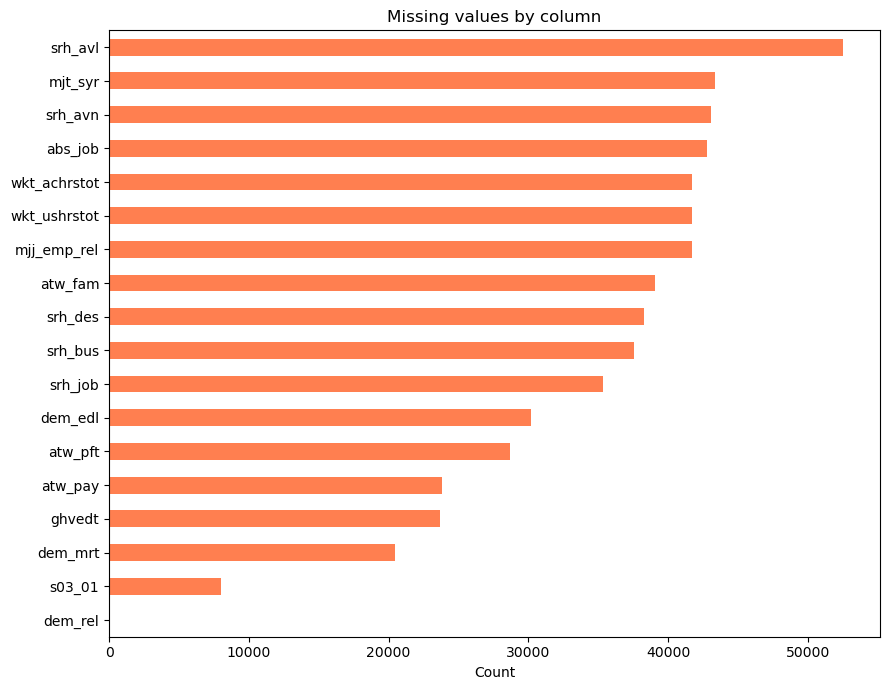

In [19]:
counts = df.isna().sum()
counts[counts > 0].sort_values().plot(kind='barh', color='coral', figsize=(9, 7))
plt.title('Missing values by column')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

**Answers:**

- A large block sits between 44% and 98.5% missing, and almost none of it is
  damage.
- The 78% group is the labour module: only people routed into it answer. The
  98.5% column is `srh_avl`, asked only of those who said no to `srh_avn`.
- The chart shows one dense cluster of skip pattern columns and a short tail of
  genuinely complete ones. Nothing here looks like a broken export.

---

## Task 9: Missing by design is not missing by error

The textbook first move is `dropna()`. On a survey with skip patterns it is a
catastrophe. Measure it before you trust it.

In [20]:
print('Rows now:                   ', len(df))
print('Rows if we called dropna(): ', len(df.dropna()))

Rows now:                    53353


Rows if we called dropna():  0


In [21]:
# The right rule: only the identifiers are non negotiable
print('Before:', df.shape)
df = df.dropna(subset=['nidf', 'ppno'])
print('After: ', df.shape)

Before: (53353, 27)
After:  (53353, 27)


**Answers:**

- `dropna()` leaves **0 rows**. Every single person is missing at least one field,
  because nobody answers every module. A whole dataset destroyed by one habit.
- Dropping on the identifiers removes nothing here, and is still worth running: it
  states the assumption that a record without an identifier is unusable, and it
  protects you on a dirtier extract.
- Filling the labour columns would be worse than leaving them empty. A person
  outside the labour force has no usual hours, and inventing a median would
  fabricate employment.

---

## Task 10: Duplicates on a compound key

No two rows here are identical, so `duplicated()` alone finds nothing. The real
key is the pair `nidf` plus `ppno`: one row per person per household.

In [22]:
print('Exact duplicate rows:', df.duplicated().sum())

dup_mask = df.duplicated(subset=['nidf', 'ppno'], keep=False)
print('Rows sharing a person key:', dup_mask.sum())
df[dup_mask].sort_values(['nidf', 'ppno'])[
    ['nidf', 'ppno', 'dem_age', 'dem_sex', 'dem_rel', 'wkt_ushrstot']]

Exact duplicate rows: 0
Rows sharing a person key: 16


,nidf,ppno,dem_age,dem_sex,dem_rel,wkt_ushrstot
13972,10820054,1,32.00,Masculino,Chefe/Pessoa de referência,66.00
13975,10820054,1,50.00,Masculino,Chefe/Pessoa de referência,60.00
19422,10820054,2,21.00,Feminino,Cônjuge,84.00
40360,10820054,2,39.00,Feminino,Cônjuge,NaN
2035,10820054,3,22.00,Masculino,Filho (a),NaN
30764,10820054,3,4.00,Feminino,Filho (a),NaN
2033,10820054,4,19.00,Masculino,Filho (a),NaN
37618,10820054,4,2.00,Masculino,Filho (a),NaN
16865,12890006,1,36.00,Masculino,Chefe/Pessoa de referência,NaN
17451,12890006,1,23.00,Masculino,Chefe/Pessoa de referência,NaN


In [23]:
# Keep the most complete record in each group
df['missing_count'] = df.isna().sum(axis=1)

print('Before:', df.shape)
df = (
    df
    .sort_values(['nidf', 'ppno', 'missing_count'])
    .drop_duplicates(subset=['nidf', 'ppno'], keep='first')
    .drop(columns='missing_count')
)
print('After: ', df.shape)

Before: (53353, 28)


After:  (53345, 27)


**Answers:**

- Zero exact duplicates, but **16 rows in 8 duplicate pairs**. Only the compound
  key finds them, which is why choosing the key matters more than the method.
- 8 rows are removed, 53,353 down to 53,345.
- `keep=False` marks every member of a duplicate group, which is what you want
  when inspecting. The default `keep='first'` hides the first occurrence and makes
  the groups impossible to compare.
- The pairs are not near-copies: look at the ages. Household 10820054 has a person
  1 aged 32 and another aged 50. This is two different people sharing an id, not
  one person entered twice, so "keep the most complete" is a pragmatic rule and
  the real fix belongs with the data producer.

---

## Task 11: A rule that `describe()` cannot catch

Every household should have exactly one head. No summary statistic will tell you
whether that holds, because it is a relationship between rows rather than a
property of a column.

In [24]:
heads = df[df['dem_rel'] == 'Chefe/Pessoa de referência']
heads_per_household = heads['nidf'].value_counts()

print('Households with two or more heads:', (heads_per_household > 1).sum())
print('Households with no head recorded: ',
      df['nidf'].nunique() - heads_per_household.index.nunique())

Households with two or more heads: 1
Households with no head recorded:  1


**Answers:**

- **1** household still has two heads, and **35** have none.
- On the raw file, before Task 10 removed the duplicate person records, **6**
  households had two heads. Five of those were caused by the duplicates
  themselves, so deduplication fixed most of the problem. That is a good argument
  for running structural checks after cleaning rather than before.
- Neither number is visible in `describe()`. Cross row rules need their own
  checks, which is exactly why they get missed.

---

## Task 12: Save the cleaned dataset

Raw data is read only. Write the result to `10_cleaned/` and reload it to confirm
it survives the round trip.

In [25]:
os.makedirs(DATA_CLEAN_DIR, exist_ok=True)
out_path = os.path.join(DATA_CLEAN_DIR, 'angola_iea_2025q4_clean.csv')

df = df.reset_index(drop=True)
df.to_csv(out_path, index=False)
print('Saved:', out_path, '|', df.shape)

Saved: ../../data/10_cleaned/angola_iea_2025q4_clean.csv | (53345, 27)


In [26]:
check = pd.read_csv(out_path, dtype={'nidf': 'string', 'ppno': 'string',
                                     'g_06_id_iea': 'string'})
print('Reloaded:', check.shape)
print()
print(check[['nidf', 'prov', 'ghvedt', 'mjt_syr']].dtypes)
check[['nidf', 'prov', 'dem_age', 'ghvedt', 'mjt_syr']].head()

Reloaded: (53345, 27)

nidf       string[python]
prov               object
ghvedt             object
mjt_syr           float64
dtype: object


,nidf,prov,dem_age,ghvedt,mjt_syr
0,10000003,Huila,55.00,2025-12-14,NaN
1,10000003,Huila,52.00,2025-12-14,NaN
2,10000003,Huila,19.00,2025-12-14,NaN
3,10000003,Huila,16.00,2025-12-14,NaN
4,10000009,Huila,43.00,2025-12-14,NaN


**Answers:**

- The cleaned file is **53,345 rows by 27 columns**, 8 fewer rows than we loaded.
  Every removal is countable and explainable, which is what makes cleaning
  defensible to somebody who did not do it.
- `ghvedt` reloads as plain text and `prov` reloads as text rather than
  `category`. CSV stores no dtypes, so every reader has to re-establish them. That
  is the price of a portable format.
- `index=False` stops pandas writing the row numbers as a nameless first column,
  which would come back as `Unnamed: 0` on the next read.